# Experiment 01.01 — BTW Sandpile SOC Signature Validation

Validate diagnostic functions against the Bak-Tang-Wiesenfeld sandpile, the canonical SOC system. The goal is to confirm that our signature detection tools correctly identify SOC properties in a system where criticality is guaranteed by construction.

**Reference design:** [`work/experiments/validation/01_sandpile.md`](experiments/validation/01_sandpile.md)

**Implementation:** [`work/experiments/validation/sandpile.jl`](experiments/validation/sandpile.jl), [`work/experiments/validation/diagnostics.jl`](experiments/validation/diagnostics.jl)

## Setup

In [1]:
include("experiments/validation/load_validation.jl")

using DataFrames
using Statistics
using Printf

## Configuration

Select ensemble mode. `:single` runs one seed per L (quick iteration / tool verification). `:full` runs the overnight ensemble spec per L.

| Mode | L=64 | L=128 | L=256 | L=512 | L=1024 | Approx runtime |
|------|------|-------|-------|-------|--------|---------------|
| `:single` | 1 | 1 | 1 | 1 | — | ~12 min |
| `:full` | — | 40 | 30 | 20 | 10 | ~overnight |

**Memory warning for `:full`:** concatenated catalogs at L=512 (20 seeds × 200K × long wave_profiles) can exceed several GB. At L=1024, even 10 seeds may push memory. Monitor and reduce seed counts if needed.

In [ ]:
# Set to :full for the overnight ensemble run, :single for quick iteration.
ENSEMBLE_MODE = :single

N_record = 200_000

L_SEEDS = if ENSEMBLE_MODE == :full
    Dict(128 => 40, 256 => 30, 512 => 20, 1024 => 10)
elseif ENSEMBLE_MODE == :single
    Dict(64 => 1, 128 => 1, 256 => 1, 512 => 1)
else
    error("ENSEMBLE_MODE must be :single or :full")
end

L_values = sort(collect(keys(L_SEEDS)))

println("Mode: $ENSEMBLE_MODE")
println("L values: $L_values")
for L in L_values
    @printf("  L=%d : %d seed(s)\n", L, L_SEEDS[L])
end

## 1. Smoke test — small lattice

Run a tiny BTW sandpile to verify the simulator works end-to-end before doing anything expensive.

In [2]:
smoke = btw_sandpile(32; N_transient=10_000, N_record=10_000, seed=1)

smoke_sizes = avalanche_sizes(smoke.catalog)

println("Smoke test — L=32, N_record=10,000:")
@printf("  Mean lattice height: %.3f (expected ~2.125 for BTW)\n", mean(smoke.final_height))
@printf("  Non-empty avalanches: %d / %d\n", length(smoke_sizes), length(smoke.catalog))
@printf("  Mean avalanche size:  %.2f\n", mean(smoke_sizes))
@printf("  Max avalanche size:   %d\n", maximum(smoke_sizes))

Smoke test — L=32, N_record=10,000:
  Mean lattice height: 2.080 (expected ~2.125 for BTW)
  Non-empty avalanches: 4216 / 10000
  Mean avalanche size:  95.46
  Max avalanche size:   2137


## 1b. Burn-in convergence trace

With `:empty` initial condition, there is no clean "now at criticality" signal — only convergence diagnostics. We monitor:

- **`mean_z`** should climb monotonically and plateau at **17/8 = 2.125** (Dhar 1999, exact stationary value for 2D BTW).
- **`dissipation_rate_recent`** should rise and plateau at **1.0** (one grain leaves per grain added at steady state).
- **`mean_avalanche_size_recent`** should stabilize.

Run once per lattice size to choose an appropriate `N_transient` for production runs.

In [3]:
trace_L = 64
trace = btw_burnin_trace(trace_L;
                         N_grains=10 * trace_L * trace_L,
                         log_every=1000,
                         seed=1)
show(DataFrame(trace), allrows=true, allcols=true)

40×5 DataFrame
 Row │ step   mean_z    cumulative_dissipation  dissipation_rate_recent  mean_avalanche_size_recent 
     │ Int64  Float64   Int64                   Float64                  Float64                    
─────┼──────────────────────────────────────────────────────────────────────────────────────────────
   1 │  1000  0.244141                       0                    0.0                         0.001
   2 │  2000  0.488281                       0                    0.0                         0.004
   3 │  3000  0.732422                       0                    0.0                         0.025
   4 │  4000  0.976074                       2                    0.002                       0.061
   5 │  5000  1.21802                       11                    0.009                       0.148
   6 │  6000  1.45874                       25                    0.014                       0.268
   7 │  7000  1.69775                       46                    0.021           

**Reading the table:** find the step where `mean_z` first exceeds ~2.10 and stays there, and where `dissipation_rate_recent` is consistently near 1.0. That step is the empirical N_transient for this lattice size. Round up for safety. The default `10 × L²` used below is conservative.

In [4]:
# Optional: same trace from :overloaded initial condition for comparison.
# Should converge much faster (the initial cascade does most of the work).
trace_overloaded = btw_burnin_trace(trace_L;
                                    N_grains=2 * trace_L * trace_L,
                                    log_every=1000,
                                    initial_condition=:overloaded,
                                    seed=1)
DataFrame(trace_overloaded)

Row,step,mean_z,cumulative_dissipation,dissipation_rate_recent,mean_avalanche_size_recent
,Int64,Float64,Int64,Float64,Float64
1,1000,2.11182,988,0.988,152.727
2,2000,2.10107,2032,1.044,156.843
3,3000,2.10107,3032,1.0,157.67
4,4000,2.09644,4051,1.019,152.64
5,5000,2.10083,5033,0.982,154.093
6,6000,2.10327,6023,0.99,149.048
7,7000,2.09595,7053,1.03,154.394
8,8000,2.12036,7953,0.9,138.868


## 1c. Adaptive burn-in

Rather than hardcoding `N_transient` as a multiple of L², detect steady state from the observed signals: `mean_z` plateau + `dissipation_rate` near 1.0. This works for any L and any initial condition.

Convergence criterion (default):
- Range of `mean_z` over last 5 check windows < 0.02
- Mean of `dissipation_rate_recent` over last 5 windows in [0.9, 1.1]

Returns the burn-in trace so you can see when and how convergence happened.

In [5]:
# Empty start — should converge around step ~10K for L=64
adaptive_empty = btw_sandpile_adaptive(64;
                                       N_record=50_000,
                                       initial_condition=:empty,
                                       seed=42)
@printf("Empty start:      converged=%s  burnin=%d grains\n",
        adaptive_empty.converged, adaptive_empty.n_burnin_grains)

# Overloaded start — should converge immediately
adaptive_over = btw_sandpile_adaptive(64;
                                     N_record=50_000,
                                     initial_condition=:overloaded,
                                     seed=42)
@printf("Overloaded start: converged=%s  burnin=%d grains\n",
        adaptive_over.converged, adaptive_over.n_burnin_grains)

Empty start:      converged=true  burnin=14000 grains
Overloaded start: converged=true  burnin=5000 grains


In [6]:
# Inspect the burn-in trace to see the convergence path
show(DataFrame(adaptive_empty.burnin_trace), allrows=true, allcols=true)

14×5 DataFrame
 Row │ step   mean_z    cumulative_dissipation  dissipation_rate_recent  mean_avalanche_size_recent 
     │ Int64  Float64   Int64                   Float64                  Float64                    
─────┼──────────────────────────────────────────────────────────────────────────────────────────────
   1 │  1000  0.244141                       0                    0.0                         0.001
   2 │  2000  0.488281                       0                    0.0                         0.005
   3 │  3000  0.732178                       1                    0.001                       0.027
   4 │  4000  0.974854                       7                    0.006                       0.08
   5 │  5000  1.21729                       14                    0.007                       0.152
   6 │  6000  1.45728                       31                    0.017                       0.337
   7 │  7000  1.69702                       49                    0.018            

## 2. Production runs

Loops over `L_values` (set by the Configuration cell), running `L_SEEDS[L]` seeded realizations per L. Uses `btw_sandpile_adaptive` — burn-in length determined by convergence detection.

Downstream diagnostic cells access `results[L].catalog` (concatenated across seeds) for pooled statistics and `results[L].per_seed` for per-seed work (error bars, ensemble fluctuations).

In [7]:
# Loop over L, running n_seeds realizations per L.
# Each realization gets its own seed. Catalogs are concatenated
# across seeds for downstream diagnostics; per-seed results are
# also stored for ensemble-statistics work.
results = Dict{Int, NamedTuple}()

for L in L_values
    n_seeds = L_SEEDS[L]
    per_seed = NamedTuple[]
    @printf("L=%d: n_seeds=%d  record=%d per seed\n", L, n_seeds, N_record)
    for s in 1:n_seeds
        t = @elapsed res = btw_sandpile_adaptive(L;
                               N_record=N_record,
                               seed=s)
        push!(per_seed, res)
        @printf("  seed=%d: %.1fs  burnin=%d  converged=%s  mean_z=%.3f\n",
                s, t, res.n_burnin_grains, res.converged,
                mean(res.final_height))
    end
    # Concatenate catalogs across seeds for downstream cells.
    all_catalogs = reduce(vcat, [p.catalog for p in per_seed])
    results[L] = (
        catalog = all_catalogs,
        final_height = per_seed[end].final_height,
        per_seed = per_seed,
        n_seeds = n_seeds,
    )
    @printf("  TOTAL for L=%d: %d avalanches across %d seed(s)\n\n",
            L, length(all_catalogs), n_seeds)
end

L=64: record=200000 ... done in 3.1s  burnin=5000 grains  converged=true  mean_height=2.095
L=128: record=200000 ... done in 10.7s  burnin=5000 grains  converged=true  mean_height=2.117
L=256: record=200000 ... done in 64.8s  burnin=5000 grains  converged=true  mean_height=2.118
L=512: record=200000 ... done in 666.2s  burnin=5000 grains  converged=true  mean_height=2.122


### Catalog summary

In [8]:
summary_rows = NamedTuple[]
for L in L_values
    sizes = avalanche_sizes(results[L].catalog)
    durations = avalanche_durations(results[L].catalog)
    push!(summary_rows, (
        L = L,
        n_recorded = length(results[L].catalog),
        n_nonempty = length(sizes),
        mean_size = mean(sizes),
        median_size = median(sizes),
        max_size = maximum(sizes),
        mean_duration = mean(durations),
        max_duration = maximum(durations),
        mean_height = mean(results[L].final_height),
    ))
end
DataFrame(summary_rows)

Row,L,n_recorded,n_nonempty,mean_size,median_size,max_size,mean_duration,max_duration,mean_height
,Int64,Int64,Int64,Float64,Float64,Int64,Float64,Int64,Float64
1,64,200000,87425,349.381,28.0,17413,39.3098,831,2.09497
2,128,200000,88694,1335.65,42.0,122657,79.3994,2764,2.11694
3,256,200000,88725,5267.31,53.0,734046,159.025,9691,2.11784
4,512,200000,88961,20847.5,61.0,3999359,312.237,22987,2.12238


## 3. Signature 1 — Power-law avalanche size distribution

Expected: tau_s ≈ 1.2 (effective; BTW exhibits multiscaling per Tebaldi et al. 1999, so a single exponent is approximate).

In [9]:
pl_rows = NamedTuple[]
for L in L_values
    sizes = avalanche_sizes(results[L].catalog)
    fit = fit_power_law(Float64.(sizes))
    cmp = compare_power_law_exponential(Float64.(sizes), fit.xmin, fit.alpha)
    push!(pl_rows, (
        L = L,
        xmin = fit.xmin,
        alpha = fit.alpha,
        sigma_alpha = fit.sigma_alpha,
        ks_distance = fit.ks_distance,
        n_tail = fit.n_tail,
        ll_ratio_pl_vs_exp = cmp.log_likelihood_ratio,
    ))
end
DataFrame(pl_rows)

Row,L,xmin,alpha,sigma_alpha,ks_distance,n_tail,ll_ratio_pl_vs_exp
,Int64,Float64,Float64,Float64,Float64,Int64,Float64
1,64,1736.0,2.84083,0.0264874,0.0615623,4830,-127.357
2,128,7111.0,2.52401,0.0227237,0.0545253,4498,-19.3448
3,256,21550.0,2.15119,0.0158172,0.067505,5297,128.939
4,512,2.0,1.20423,0.000725471,0.069826,79252,2.55895e5


### 3a. Visualize P(s) to identify the scaling regime

Clauset's auto-xmin search landed in the finite-size cutoff region. Plotting log-binned P(s) on log-log reveals the three regimes:

- **Small s** (< 10ish): deviations due to lattice discretization
- **Middle s** (~10-1000 for L=64): the scaling regime where tau_s ≈ 1.2 lives
- **Large s** (upper tail): finite-size cutoff where the distribution curves down

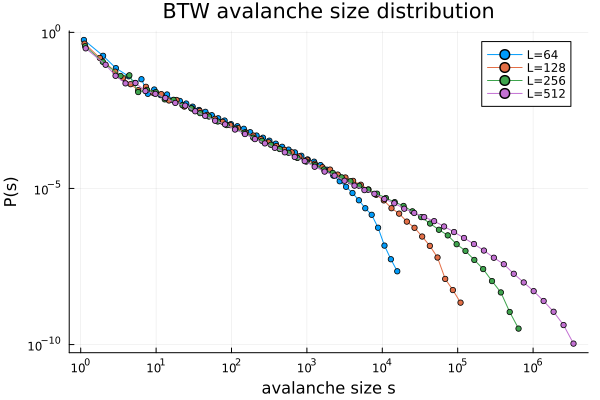

In [10]:
using Plots

p = plot(xaxis=:log, yaxis=:log,
         xlabel="avalanche size s",
         ylabel="P(s)",
         title="BTW avalanche size distribution",
         legend=:topright)

for L in L_values
    sizes = avalanche_sizes(results[L].catalog)
    h = log_binned_pmf(Float64.(sizes); n_bins=50)
    plot!(p, h.bin_centers, h.pmf, label="L=$L", marker=:circle, markersize=3)
end

p

### 3b. Manual xmin in the scaling regime

Based on the plot, fit with xmin in the middle decade (not the top 5% the auto-search found). Try a grid of xmin values to see how tau_s varies — this also makes the multiscaling visible (a true power law would give constant alpha across xmin choices).

In [11]:
manual_xmins = [5, 10, 30, 100, 300]

rows = NamedTuple[]
for L in L_values
    sizes = Float64.(avalanche_sizes(results[L].catalog))
    for xm in manual_xmins
        fit = fit_power_law(sizes; xmin=xm)
        cmp = compare_power_law_exponential(sizes, xm, fit.alpha)
        push!(rows, (
            L = L,
            xmin = xm,
            alpha = fit.alpha,
            sigma_alpha = fit.sigma_alpha,
            ks_distance = fit.ks_distance,
            n_tail = fit.n_tail,
            ll_ratio_pl_vs_exp = cmp.log_likelihood_ratio,
        ))
    end
end
DataFrame(rows)

Row,L,xmin,alpha,sigma_alpha,ks_distance,n_tail,ll_ratio_pl_vs_exp
,Int64,Int64,Float64,Float64,Float64,Int64,Float64
1,64,5,1.3266,0.00128858,0.117337,64241,32231.5
2,64,10,1.36905,0.00155963,0.122143,55993,19095.5
3,64,30,1.45373,0.00217996,0.12591,43321,5749.72
4,64,100,1.59784,0.00343036,0.125182,30373,-456.576
5,64,300,1.83487,0.00597371,0.118445,19532,-1315.97
6,128,5,1.27466,0.0010615,0.107894,66952,71440.5
7,128,10,1.3014,0.00123825,0.113718,59248,49877.0
8,128,30,1.35222,0.00160979,0.117455,47872,25753.8
9,128,100,1.42769,0.00224481,0.121632,36299,9640.71


### 3c. Fit the scaling regime only (xmin + xmax)

To isolate the scaling regime from the cutoff, provide both xmin and xmax. The upper xmax should exclude the region where P(s) curves away from power-law behavior. For L=64, that's roughly s < 1000 (below the visible knee in 3a).

In [12]:
# Scaling-regime fits: xmin at 10, xmax truncates the cutoff.
# Expected: tau_s closer to 1.2 (published BTW value)
regime_rows = NamedTuple[]
for (L, xmax_L) in [(64, 1000.0), (128, 4000.0), (256, 16000.0), (512, 64000.0)]
    sizes = Float64.(avalanche_sizes(results[L].catalog))
    fit = fit_power_law(sizes; xmin=10.0, xmax=xmax_L)
    push!(regime_rows, (
        L = L,
        xmin = 10.0,
        xmax = xmax_L,
        alpha_scaling_regime = fit.alpha,
        sigma_alpha = fit.sigma_alpha,
        ks_distance = fit.ks_distance,
        n_tail = fit.n_tail,
    ))
end
DataFrame(regime_rows)

Row,L,xmin,xmax,alpha_scaling_regime,sigma_alpha,ks_distance,n_tail
,Int64,Float64,Float64,Float64,Float64,Float64,Int64
1,64,10.0,1000.0,1.45425,0.00209509,0.129281,47009
2,128,10.0,4000.0,1.36036,0.00158969,0.121749,51386
3,256,10.0,16000.0,1.30663,0.00132338,0.11029,53686
4,512,10.0,64000.0,1.2736,0.00115957,0.0943329,55672


### 3d. Area distribution — cleaner scaling than size

Tebaldi, De Menech, Stella (1999) showed the BTW avalanche *area* (distinct sites toppled) obeys clean simple finite-size scaling — unlike the size distribution which has multiscaling. Expected tau_a ≈ 1.37.

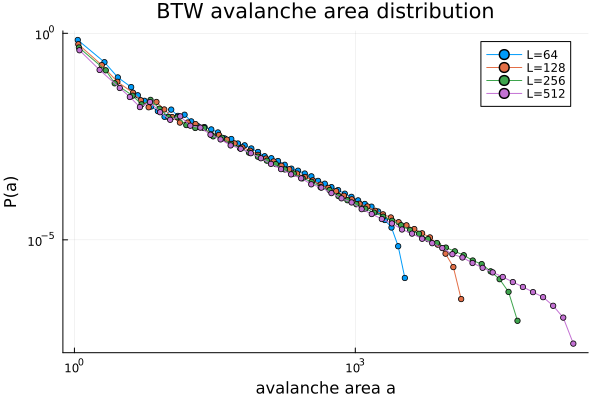

In [13]:
p_area = plot(xaxis=:log, yaxis=:log,
              xlabel="avalanche area a",
              ylabel="P(a)",
              title="BTW avalanche area distribution",
              legend=:topright)

area_rows = NamedTuple[]
for L in L_values
    areas = Float64.(avalanche_areas(results[L].catalog))
    h = log_binned_pmf(areas; n_bins=50)
    plot!(p_area, h.bin_centers, h.pmf, label="L=$L",
          marker=:circle, markersize=3)

    fit = fit_power_law(areas)  # auto xmin — should work better for area
    push!(area_rows, (
        L = L,
        xmin = fit.xmin,
        alpha_area = fit.alpha,
        sigma_alpha = fit.sigma_alpha,
        ks_distance = fit.ks_distance,
        n_tail = fit.n_tail,
    ))
end
p_area

In [14]:
DataFrame(area_rows)

Row,L,xmin,alpha_area,sigma_alpha,ks_distance,n_tail
,Int64,Float64,Float64,Float64,Float64,Int64
1,64,1373.0,4.18237,0.0473559,0.109705,4516
2,128,3.0,1.26425,0.00097898,0.110722,72857
3,256,4.0,1.2463,0.000929357,0.0977345,70239
4,512,4.0,1.22692,0.000853176,0.0850381,70741


Same fit for duration distribution (tau_t expected ~1.4-1.5):

In [15]:
dur_rows = NamedTuple[]
for L in L_values
    durs = avalanche_durations(results[L].catalog)
    fit = fit_power_law(Float64.(durs))
    push!(dur_rows, (
        L = L,
        xmin = fit.xmin,
        alpha_duration = fit.alpha,
        sigma_alpha = fit.sigma_alpha,
        ks_distance = fit.ks_distance,
        n_tail = fit.n_tail,
    ))
end
DataFrame(dur_rows)

Row,L,xmin,alpha_duration,sigma_alpha,ks_distance,n_tail
,Int64,Float64,Float64,Float64,Float64,Int64
1,64,170.0,4.28871,0.0495173,0.0672631,4411
2,128,386.0,3.76074,0.040892,0.0536965,4558
3,256,857.0,3.23655,0.0335688,0.0644433,4439
4,512,1807.0,2.90682,0.0285845,0.0740333,4450


## 4. Signature 2 — Spatial correlation in the height field

G(r) should decay as a power law (with logarithmic corrections in BTW), not exponentially. Expensive at large L; sample if needed.

In [16]:
# Compute G(r) for L=64 and L=128 (O(L^4) — L=128 takes ~20s,
# L=256+ infeasible). Plot both on log-log.
corr_data = Dict{Int, NamedTuple}()
for L in [128, 256]
    @printf("Computing G(r) for L=%d ... ", L)
    t = @elapsed corr_data[L] = correlation_function(
        results[L].final_height; max_r=div(L, 4))
    @printf("done in %.1fs\n", t)
end

p_corr = plot(xaxis=:log, yaxis=:log,
              xlabel="distance r",
              ylabel="|G(r)|",
              title="Height-height correlation function",
              legend=:topright)
for L in [128, 256]
    c = corr_data[L]
    # Plot |G(r)| on log-log to show decay shape; r=1 is often
    # negative (anti-correlated from toppling) and excluded
    mask = c.G .!= 0
    plot!(p_corr, c.r[mask], abs.(c.G[mask]),
          label="L=$L", marker=:circle, markersize=4)
end
p_corr

Height-height correlation G(r) at L=64:
  r= 1  G(r)=-0.0562  (n_pairs=32004)
  r= 2  G(r)= 0.0049  (n_pairs=47120)
  r= 3  G(r)= 0.0189  (n_pairs=61736)
  r= 4  G(r)= 0.0255  (n_pairs=120500)
  r= 5  G(r)= 0.0309  (n_pairs=103384)
  r= 6  G(r)= 0.0277  (n_pairs=144360)
  r= 7  G(r)= 0.0231  (n_pairs=141660)
  r= 8  G(r)= 0.0324  (n_pairs=166344)
  r= 9  G(r)= 0.0307  (n_pairs=229912)
  r=10  G(r)= 0.0308  (n_pairs=185516)
  r=11  G(r)= 0.0272  (n_pairs=232520)
  r=12  G(r)= 0.0296  (n_pairs=215464)
  r=13  G(r)= 0.0294  (n_pairs=271388)
  r=14  G(r)= 0.0282  (n_pairs=265152)
  r=15  G(r)= 0.0277  (n_pairs=248136)
  r=16  G(r)= 0.0281  (n_pairs=321556)


## 5. Signature 3 — Spectral analysis

Compute PSD of the avalanche size time series. **Note:** BTW does NOT produce clean 1/f noise. Expected high-frequency exponent ~1.56 with three distinct frequency regimes (Chhimpa et al. 2025).

In [17]:
# Build microscopic time series: topplings per wave, concatenated
# across all avalanches in temporal order. This is the Bak-Tang-Wiesenfeld
# 1987 signal where 1/f noise actually lives. The macroscopic series
# (size per grain drop) is nearly white because avalanches are
# nearly independent at the grain-drop scale.
spec_rows = NamedTuple[]
spec_data = Dict{Int, NamedTuple}()
for L in L_values
    micro = microscopic_activity_series(results[L].catalog)
    spec = power_spectrum(Float64.(micro))
    # Fit beta in middle decade (skip lowest/highest 10%)
    beta_fit = spectral_exponent(spec.freq, spec.psd)
    h = hurst_rs(Float64.(micro))
    spec_data[L] = (freq=spec.freq, psd=spec.psd, micro=micro)
    push!(spec_rows, (
        L = L,
        n_waves = length(micro),
        beta = beta_fit.beta,
        beta_n_used = beta_fit.n_used,
        hurst = h.H,
    ))
end
DataFrame(spec_rows)

Row,L,beta,beta_n_used,hurst,hurst_n_scales
,Int64,Float64,Int64,Float64,Int64
1,64,0.00585078,79999,0.366542,20
2,128,-0.0118417,79999,0.396136,20
3,256,-0.0198622,79999,0.436858,20
4,512,-0.00603477,79999,0.472279,20


In [ ]:
# PSD log-log plot — look for 1/f^beta scaling (expected beta ~1.5 for BTW)
p_psd = plot(xaxis=:log, yaxis=:log,
             xlabel="frequency f",
             ylabel="PSD S(f)",
             title="Power spectral density (microscopic time)",
             legend=:topright)
for L in L_values
    d = spec_data[L]
    # Subsample for plotting readability
    n = length(d.freq)
    stride = max(1, div(n, 300))
    idx = 1:stride:n
    plot!(p_psd, d.freq[idx], d.psd[idx], label="L=$L", alpha=0.7)
end
p_psd

## 6. Signature 4 — Fractal structure of avalanche frontiers

BTW avalanche clusters are approximately compact (D ≈ 2). The fractal property is in the **frontier** (boundary), expected D_frontier ≈ 1.25 (Moghimi-Araghi et al. 2009).

For now we measure the cluster footprint dimension; frontier extraction can be added later.

In [18]:
# Re-run a small set of avalanches with site tracking would require modifying
# the simulator. The current AvalancheRecord only stores aggregate stats.
# For now: report the size-area scaling exponent as a proxy.
#
# s ~ a^gamma where gamma > 1 indicates multiple topplings per site (BTW signature)

fractal_rows = NamedTuple[]
for L in L_values
    catalog = results[L].catalog
    nonempty = [a for a in catalog if a.size > 0]
    sizes = Float64.([a.size for a in nonempty])
    areas = Float64.([a.area for a in nonempty])
    # Fit log(size) vs log(area) on the upper half (large avalanches)
    big_mask = sizes .>= quantile(sizes, 0.5)
    log_s = log.(sizes[big_mask])
    log_a = log.(areas[big_mask])
    mean_x = mean(log_a)
    mean_y = mean(log_s)
    gamma = sum((log_a .- mean_x) .* (log_s .- mean_y)) / sum((log_a .- mean_x).^2)
    push!(fractal_rows, (
        L = L,
        size_area_exponent_gamma = gamma,
        n_used = sum(big_mask),
    ))
end
DataFrame(fractal_rows)

Row,L,size_area_exponent_gamma,n_used
,Int64,Float64,Int64
1,64,1.08332,44053
2,128,1.08958,44486
3,256,1.09448,44366
4,512,1.09401,44513


## 7. Signature 5 — Fat-tailed changes

Excess kurtosis of first differences in rolling avalanche activity. Expected: K > 1.5.

In [19]:
kurt_rows = NamedTuple[]
for L in L_values
    series = avalanche_sizes(results[L].catalog; exclude_empty=false)
    raw = fat_tail_kurtosis(Float64.(series); window=1)
    win100 = fat_tail_kurtosis(Float64.(series); window=100)
    win1000 = fat_tail_kurtosis(Float64.(series); window=1000)
    push!(kurt_rows, (
        L = L,
        excess_kurtosis_raw = raw.excess_kurtosis,
        excess_kurtosis_w100 = win100.excess_kurtosis,
        excess_kurtosis_w1000 = win1000.excess_kurtosis,
    ))
end
DataFrame(kurt_rows)

Row,L,excess_kurtosis_raw,excess_kurtosis_w100,excess_kurtosis_w1000
,Int64,Float64,Float64,Float64
1,64,45.5045,45.938,45.6846
2,128,97.1243,97.2937,95.8011
3,256,167.361,167.812,167.48
4,512,264.607,264.743,263.759


## 8. Branching ratio (activity-dependent)

Per Michiels van Kessenich et al. (2010): a single global b is misleading. Look for a **broad activity range where b(x) ≈ 1** — that is the SOC signature.

In [20]:
for L in L_values
    bx = branching_ratio_activity_dependent(results[L].catalog; n_bins=20)
    global_b = branching_ratio_global(results[L].catalog)
    println("L=$L:")
    @printf("  Global mean b: %.3f\n", global_b)
    println("  Activity-dependent b(x):")
    for (a, b, n) in zip(bx.activity_levels, bx.b_of_x, bx.n_in_bin)
        @printf("    activity ~ %7.1f   b(x) = %.3f   (n=%d)\n", a, b, n)
    end
    println()
end

L=64:
  Global mean b: 1.071
  Activity-dependent b(x):
    activity ~     1.1   b(x) = 1.592   (n=272862)
    activity ~     1.8   b(x) = 1.168   (n=311808)
    activity ~     3.0   b(x) = 1.075   (n=311255)
    activity ~     3.8   b(x) = 1.040   (n=282305)
    activity ~     4.8   b(x) = 1.021   (n=253636)
    activity ~     6.1   b(x) = 1.011   (n=226356)
    activity ~     7.8   b(x) = 1.002   (n=374568)
    activity ~     9.9   b(x) = 0.991   (n=409979)
    activity ~    12.7   b(x) = 0.986   (n=279404)
    activity ~    16.1   b(x) = 0.982   (n=239816)
    activity ~    20.5   b(x) = 0.979   (n=172544)
    activity ~    26.2   b(x) = 0.978   (n=107842)
    activity ~    33.3   b(x) = 0.977   (n=65526)
    activity ~    42.4   b(x) = 0.973   (n=29281)
    activity ~    54.1   b(x) = 0.971   (n=9473)
    activity ~    68.8   b(x) = 0.970   (n=2156)
    activity ~    87.7   b(x) = 0.976   (n=362)
    activity ~   111.7   b(x) = 0.975   (n=59)

L=128:
  Global mean b: 1.046
  Activi

In [ ]:
# Activity-dependent branching ratio b(x) — look for broad plateau at b≈1
p_bx = plot(xaxis=:log,
            xlabel="activity level n_t",
            ylabel="b(x)",
            title="Activity-dependent branching ratio",
            legend=:topright)
hline!(p_bx, [1.0], linestyle=:dash, color=:black, label="b=1 (critical)")
for L in L_values
    bx = branching_ratio_activity_dependent(results[L].catalog; n_bins=20)
    plot!(p_bx, bx.activity_levels, bx.b_of_x,
          label="L=$L", marker=:circle, markersize=4)
end
p_bx

## 9. Inter-event time distribution

Waiting times between avalanches above selected thresholds. Expected: power-law or stretched exponential at high thresholds, no characteristic waiting time.

In [21]:
for L in L_values
    series = avalanche_sizes(results[L].catalog; exclude_empty=false)
    nonempty = avalanche_sizes(results[L].catalog)
    println("L=$L thresholds and waiting time stats:")
    for q in [0.50, 0.90, 0.99]
        thr = quantile(Float64.(nonempty), q)
        waits = inter_event_times(Float64.(series), thr)
        if length(waits) >= 10
            @printf("  q=%.2f  thr=%.0f  n_waits=%d  mean=%.1f  median=%.1f  max=%d\n",
                    q, thr, length(waits), mean(waits), median(waits), maximum(waits))
        else
            @printf("  q=%.2f  thr=%.0f  n_waits=%d  (insufficient)\n",
                    q, thr, length(waits))
        end
    end
    println()
end

L=64 thresholds and waiting time stats:
  q=0.50  thr=28  n_waits=44052  mean=4.5  median=3.0  max=43
  q=0.90  thr=1028  n_waits=8747  mean=22.9  median=17.0  max=197
  q=0.99  thr=4469  n_waits=874  mean=228.8  median=188.0  max=1167

L=128 thresholds and waiting time stats:
  q=0.50  thr=42  n_waits=44485  mean=4.5  median=3.0  max=47
  q=0.90  thr=3414  n_waits=8869  mean=22.5  median=16.0  max=181
  q=0.99  thr=21738  n_waits=886  mean=224.7  median=171.0  max=1380

L=256 thresholds and waiting time stats:
  q=0.50  thr=53  n_waits=44365  mean=4.5  median=3.0  max=40
  q=0.90  thr=10119  n_waits=8872  mean=22.5  median=16.0  max=215
  q=0.99  thr=101459  n_waits=887  mean=225.3  median=157.0  max=1288

L=512 thresholds and waiting time stats:
  q=0.50  thr=61  n_waits=44512  mean=4.5  median=3.0  max=37
  q=0.90  thr=26742  n_waits=8895  mean=22.5  median=16.0  max=165
  q=0.99  thr=442950  n_waits=889  mean=224.7  median=153.0  max=1153



---

## 11. Ensemble analysis

These cells produce per-seed statistics and ensemble error bars. They are meaningful when `ENSEMBLE_MODE = :full`; in `:single` mode there is only one seed per L so no variance is measurable.

Deliverables:
1. Per-seed alpha at fixed xmin → mean ± std across seeds
2. Multiscaling drift curves with error bars
3. Per-seed area-distribution alpha (cleaner than size)
4. Finite-size extrapolation with error bars — plot alpha vs 1/L, fit, report asymptotic alpha ± uncertainty
5. Per-seed branching ratio plateau quality

In [ ]:
# Gate these cells so they warn (but don't error) in :single mode
has_ensemble = maximum(values(L_SEEDS)) > 1
if !has_ensemble
    @info "Ensemble analysis cells will produce degenerate results in :single mode."
end

### 11a. Per-seed alpha at fixed xmin

For each (L, seed), fit tau_s with xmin=5 (inside the scaling regime). Report mean ± std across seeds per L. This is the honest ensemble error bar on alpha.

In [ ]:
per_seed_alpha_rows = NamedTuple[]
fixed_xmin = 5.0
for L in L_values
    alphas = Float64[]
    for p in results[L].per_seed
        sizes = Float64.(avalanche_sizes(p.catalog))
        fit = fit_power_law(sizes; xmin=fixed_xmin)
        if !isnan(fit.alpha)
            push!(alphas, fit.alpha)
        end
    end
    push!(per_seed_alpha_rows, (
        L = L,
        n_seeds = length(alphas),
        alpha_mean = isempty(alphas) ? NaN : mean(alphas),
        alpha_std = length(alphas) > 1 ? std(alphas) : NaN,
        alpha_min = isempty(alphas) ? NaN : minimum(alphas),
        alpha_max = isempty(alphas) ? NaN : maximum(alphas),
    ))
end
DataFrame(per_seed_alpha_rows)

### 11b. Multiscaling drift with error bars

Alpha as a function of xmin, averaged across seeds. The drift (alpha increases with xmin) is the multiscaling signature. With ensemble data we can test whether this drift is statistically significant at each L.

In [ ]:
multiscaling_rows = NamedTuple[]
xmin_grid = [5, 10, 30, 100, 300]
for L in L_values
    for xm in xmin_grid
        alphas = Float64[]
        for p in results[L].per_seed
            sizes = Float64.(avalanche_sizes(p.catalog))
            fit = fit_power_law(sizes; xmin=Float64(xm))
            if !isnan(fit.alpha)
                push!(alphas, fit.alpha)
            end
        end
        push!(multiscaling_rows, (
            L = L,
            xmin = xm,
            alpha_mean = isempty(alphas) ? NaN : mean(alphas),
            alpha_std = length(alphas) > 1 ? std(alphas) : NaN,
            n_seeds = length(alphas),
        ))
    end
end
DataFrame(multiscaling_rows)

In [ ]:
# Plot alpha vs xmin with error bars by L
p_drift = plot(xaxis=:log,
               xlabel="xmin",
               ylabel="alpha (mean ± std across seeds)",
               title="Multiscaling drift in alpha",
               legend=:topleft)
for L in L_values
    rows = filter(r -> r.L == L, multiscaling_rows)
    xs = [r.xmin for r in rows]
    ys = [r.alpha_mean for r in rows]
    errs = [isnan(r.alpha_std) ? 0.0 : r.alpha_std for r in rows]
    plot!(p_drift, xs, ys, yerror=errs,
          label="L=$L", marker=:circle, markersize=5)
end
p_drift

### 11c. Per-seed area distribution alpha

The area distribution has cleaner scaling than size (Tebaldi et al. 1999). Auto-xmin should work and give tight ensemble error bars.

In [ ]:
area_ensemble_rows = NamedTuple[]
for L in L_values
    area_alphas = Float64[]
    area_xmins = Float64[]
    for p in results[L].per_seed
        areas = Float64.(avalanche_areas(p.catalog))
        fit = fit_power_law(areas)  # auto xmin
        if !isnan(fit.alpha)
            push!(area_alphas, fit.alpha)
            push!(area_xmins, fit.xmin)
        end
    end
    push!(area_ensemble_rows, (
        L = L,
        n_seeds = length(area_alphas),
        alpha_area_mean = isempty(area_alphas) ? NaN : mean(area_alphas),
        alpha_area_std = length(area_alphas) > 1 ? std(area_alphas) : NaN,
        xmin_median = isempty(area_xmins) ? NaN : median(area_xmins),
    ))
end
DataFrame(area_ensemble_rows)

### 11d. Finite-size extrapolation

Fit `alpha(L) = alpha_infinity + C / L^omega` using the per-seed means and error bars. The extrapolated `alpha_infinity` should match the asymptotic BTW exponent. The fit uncertainty is a real measurement of how close we are to the thermodynamic limit.

In [ ]:
# Extract (L, alpha_mean, alpha_std) for the fixed-xmin=5 fit from 11a
fs_data = [(r.L, r.alpha_mean, r.alpha_std) for r in per_seed_alpha_rows
           if !isnan(r.alpha_mean)]

if length(fs_data) >= 3
    Ls = [Float64(d[1]) for d in fs_data]
    alphas = [d[2] for d in fs_data]
    sigmas = [isnan(d[3]) ? 1e-6 : max(d[3], 1e-6) for d in fs_data]

    # Simple two-parameter fit: alpha = a_inf + c * L^(-1)
    # (omega=1 default; can be generalized if needed)
    x = 1.0 ./ Ls
    # Weighted linear regression: alpha = a_inf + c * x, weights = 1/sigma^2
    w = 1.0 ./ (sigmas .^ 2)
    sw = sum(w)
    sx = sum(w .* x)
    sy = sum(w .* alphas)
    sxx = sum(w .* x .^ 2)
    sxy = sum(w .* x .* alphas)
    denom = sw * sxx - sx^2
    c_fit = (sw * sxy - sx * sy) / denom
    a_inf = (sy - c_fit * sx) / sw

    # Standard errors
    var_a = sxx / denom
    var_c = sw / denom
    sigma_a_inf = sqrt(var_a)
    sigma_c = sqrt(var_c)

    @printf("Finite-size extrapolation: alpha(L) = alpha_inf + c / L\n")
    @printf("  alpha_inf = %.4f ± %.4f\n", a_inf, sigma_a_inf)
    @printf("  c         = %.4f ± %.4f\n", c_fit, sigma_c)

    p_fs = plot(xlabel="1/L", ylabel="alpha (xmin=5)",
                title="Finite-size extrapolation", legend=:bottomright)
    scatter!(p_fs, x, alphas, yerror=sigmas, label="measured", markersize=6)
    xs_dense = range(0, maximum(x)*1.05, length=50)
    plot!(p_fs, xs_dense, a_inf .+ c_fit .* xs_dense,
          label=@sprintf("fit: α_∞=%.3f", a_inf), linestyle=:dash)
    hline!(p_fs, [a_inf], color=:black, linestyle=:dot, label=nothing)
    p_fs
else
    println("Need at least 3 L values for extrapolation — currently have $(length(fs_data))")
end

## 10. Summary against published values

Compare what we measured to literature for 2D BTW. See [`01_sandpile.md`](experiments/validation/01_sandpile.md) §References for sources.

| Quantity | Expected | Status |
|----------|----------|--------|
| Mean height | 2.125 (exact, Dhar 1999) | Compare to `mean_height` above |
| tau_s (size) | ~1.2 effective; multiscaling | Compare to `alpha` in Section 3 |
| tau_t (duration) | ~1.4-1.5 | Compare to `alpha_duration` in Section 3 |
| PSD beta | ~1.56 high-freq (NOT 1/f) | Compare to `beta` in Section 5 |
| Hurst H | > 0.5 (persistent) | Compare to `hurst` in Section 5 |
| Excess kurtosis | > 1.5 | Compare in Section 7 |
| Branching b(x) | broad regime ≈ 1 | Compare in Section 8 |

**Next steps when this passes:**
- Increase to L=256 and N_record=10⁶ for production exponents
- Add negative controls (Poisson, subcritical, supercritical)
- Implement frontier extraction for true fractal dimension measurement
- Multiscaling test: moment ratios across L values
- Add Manna model for universality-class comparison (deferred per Experiment 01.02)